Read two FITS images, subtract them (`a - b`), and plot the 2D residuals.

In [8]:
from pathlib import Path

import numpy as np
from astropy.io import fits
from astropy.visualization import ZScaleInterval
from matplotlib import pyplot as plt

# Edit these paths
stem = "/Users/eckhartspalding/Documents/git.repos/metis_work/METIS_MAIT_code_eckhart/data/IMG_OPT_03_psf_quality_simmed_data"
file_a = Path(stem + "/noiseless_1st_order_IMG_OPT_03_wcu_focal_mask_bckgrnd_subted_grid_lm_pupil_mask_PPS-CFO2_filter_Br_alpha.fits")
file_b = Path(stem + "/noiseless_3rd_order_IMG_OPT_03_wcu_focal_mask_bckgrnd_subted_grid_lm_pupil_mask_PPS-CFO2_filter_Br_alpha.fits")
hdu_index = 1  # SIM science arrays are often HDU 1; use 0 for single-extension FITS


def load_image(path, hdu_index=1):
    with fits.open(path, memmap=False) as hdul:
        if hdu_index < len(hdul) and hdul[hdu_index].data is not None:
            data = hdul[hdu_index].data
        else:
            data = hdul[0].data
        return np.array(data, copy=True, dtype=float)


img_a = load_image(file_a, hdu_index=hdu_index)
img_b = load_image(file_b, hdu_index=hdu_index)
print(file_a.name, img_a.shape, img_a.dtype)
print(file_b.name, img_b.shape, img_b.dtype)

noiseless_1st_order_IMG_OPT_03_wcu_focal_mask_bckgrnd_subted_grid_lm_pupil_mask_PPS-CFO2_filter_Br_alpha.fits (2048, 2048) float64
noiseless_3rd_order_IMG_OPT_03_wcu_focal_mask_bckgrnd_subted_grid_lm_pupil_mask_PPS-CFO2_filter_Br_alpha.fits (2048, 2048) float64


residuals: min=0 max=0 mean=0 rms=0


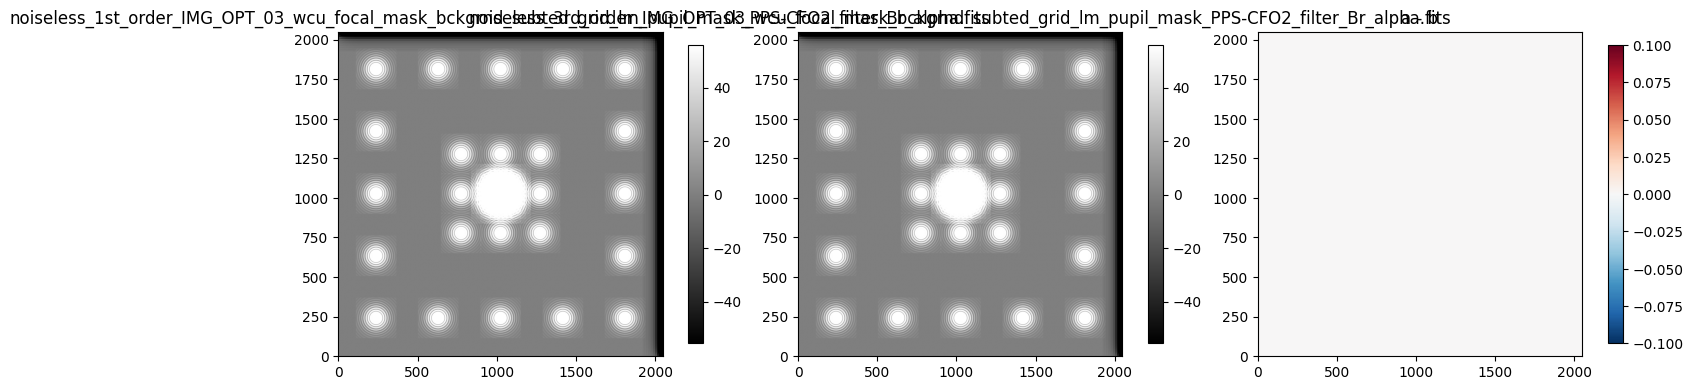

In [10]:
if img_a.shape != img_b.shape:
    raise ValueError(f"Shape mismatch: {img_a.shape} vs {img_b.shape}")

residuals = img_a - img_b
print(
    "residuals: min={:.4g} max={:.4g} mean={:.4g} rms={:.4g}".format(
        np.nanmin(residuals),
        np.nanmax(residuals),
        np.nanmean(residuals),
        np.sqrt(np.nanmean(residuals**2)),
    )
)

zscale = ZScaleInterval()
vmin, vmax = zscale.get_limits(residuals)
vlim = max(abs(vmin), abs(vmax))

fig, axs = plt.subplots(1, 3, figsize=(14, 4), constrained_layout=True)
for ax, arr, title, cmap, v in (
    (axs[0], img_a, file_a.name, "gray", zscale.get_limits(img_a)),
    (axs[1], img_b, file_b.name, "gray", zscale.get_limits(img_b)),
    (axs[2], residuals, "a - b", "RdBu_r", (-vlim, vlim)),
):
    im = ax.imshow(arr, origin="lower", cmap=cmap, vmin=v[0], vmax=v[1])
    ax.set_title(title)
    ax.set_aspect("equal")
    fig.colorbar(im, ax=ax, fraction=0.046)
plt.savefig('./junk_residuals_nth_order.png')